In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(
    "D:/Projects/fraud_detection_platform/data/raw/fraud_data.csv",
    dtype={
        "step": "int32",
        "amount": "float32",
        "isFraud": "int8",
        "isFlaggedFraud": "int8"
    }
)


In [4]:
#Drop High Cardinality IDs
df = df.drop(columns=["nameOrig","nameDest"])
df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.639648,170136.0,160296.36,0.0,0.0,0,0
1,1,PAYMENT,1864.280029,21249.0,19384.72,0.0,0.0,0,0
2,1,TRANSFER,181.000000,181.0,0.00,0.0,0.0,1,0
3,1,CASH_OUT,181.000000,181.0,0.00,21182.0,0.0,1,0
4,1,PAYMENT,11668.139648,41554.0,29885.86,0.0,0.0,0,0


In [5]:
#Fraud vs Amount Analysis
descrip=df.groupby("isFraud")["amount"].describe()
descrip

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,596237.0,0.01,13368.395020,74684.71875,2.083648e+05,92445520.0
1,8213.0,1.467967e+06,2404253.0,0.00,127091.328125,441423.43750,1.517772e+06,10000000.0


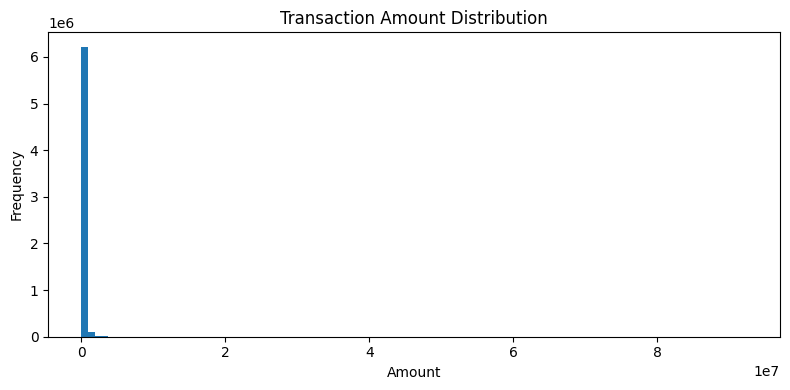

In [6]:
plt.figure(figsize=(8,4))
plt.hist(df["amount"],bins=100)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

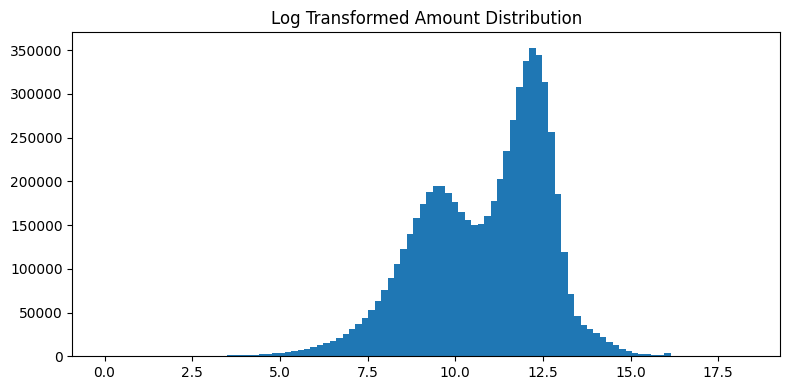

In [7]:
# Log Transformation Investigation
# Fraud datasets usually have heavily skewed amount distributions.
plt.figure(figsize=(8,4))
plt.hist(np.log1p(df["amount"]),bins=100)
plt.title("Log Transformed Amount Distribution")
plt.tight_layout()
plt.show()

In [8]:
#Fraud Amount Comparison
fraud_amounts = df[df["isFraud"] == 1]["amount"]
normal_amounts = df[df["isFraud"] == 0]["amount"]
print(fraud_amounts.describe())
print(normal_amounts.describe())

count    8.213000e+03
mean     1.467967e+06
std      2.404253e+06
min      0.000000e+00
25%      1.270913e+05
50%      4.414234e+05
75%      1.517772e+06
max      1.000000e+07
Name: amount, dtype: float64
count    6.354407e+06
mean     1.781970e+05
std      5.962370e+05
min      1.000000e-02
25%      1.336840e+04
50%      7.468472e+04
75%      2.083648e+05
max      9.244552e+07
Name: amount, dtype: float64


In [32]:
pd.crosstab( df["isFlaggedFraud"],df["isFraud"],margins=True)

isFraud,0,1,All
isFlaggedFraud,,,
0,6354407,8197,6362604
1,0,16,16
All,6354407,8213,6362620


#### Feature Engineering

##### Feature one

In [21]:
df["balance_change_orig"] = (df["oldbalanceOrg"]- df["newbalanceOrig"])
df.groupby("isFraud")["balance_change_orig"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,-2.314152e+04,1.062233e+05,-1915267.9,0.00,0.00,10102.125,4164236.31
1,8213.0,1.457275e+06,2.396099e+06,0.0,124582.58,436317.49,1503034.860,10000000.00


##### Feature Two

In [22]:
df["balance_change_dest"] = (df["newbalanceDest"]- df["oldbalanceDest"])
df.groupby("isFraud")["balance_change_dest"].describe()
df.columns

Index(['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud',
       'balance_change_dest', 'amount_to_balance_ratio',
       'balance_change_orig'],
      dtype='object')

##### Feature Three

In [23]:
df["amount_to_balance_ratio"] = (df["amount"]/(df["oldbalanceOrg"] + 1))
df.groupby("isFraud")["amount_to_balance_ratio"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,70764.320940,508745.259273,1.765480e-08,0.233401,6.511566,12355.589844,92445520.00
1,8213.0,1161.966657,32297.152335,0.000000e+00,0.999991,0.999998,0.999999,1933920.75


In [31]:
fraud_df = df[df["isFraud"] == 1]
(fraud_df["balance_change_orig"]==fraud_df["amount"]).mean()

np.float64(0.08450018263728236)

In [ ]:
#Checking Corelation Between New Features And Target Variable
numeric_cols = df.select_dtypes(include=["number"])
corr = numeric_cols.corr()
corr["isFraud"].sort_values(ascending=False)

isFraud                    1.000000
balance_change_orig        0.362472
amount                     0.076688
isFlaggedFraud             0.044109
step                       0.031578
balance_change_dest        0.027028
oldbalanceOrg              0.010154
newbalanceDest             0.000535
amount_to_balance_ratio   -0.004915
oldbalanceDest            -0.005885
newbalanceOrig            -0.008148
Name: isFraud, dtype: float64

## Day 3 Key Findings

### Amount Analysis

1. Transaction amount distribution is highly right-skewed.
2. Large transaction values naturally exist in the dataset.
3. Large values may represent fraud signals rather than data errors.
4. Outlier removal should not be performed without business justification.

### Log Transformation Analysis

1. Log transformation significantly improves amount distribution.
2. Log(amount) is a candidate feature for future experimentation.

### Fraud Amount Behavior

1. Fraudulent transactions generally involve larger transaction amounts.
2. Transaction amount appears to be an important predictive feature.

### isFlaggedFraud Analysis

1. Only 16 transactions are flagged by the banking system.
2. All flagged transactions are fraudulent.
3. The feature contains extremely strong fraud information.
4. The feature is extremely rare and may introduce target leakage.
5. Additional experimentation is required before deciding whether to keep or remove it.

### Engineered Feature Analysis

#### balance_change_orig

1. Represents money leaving the sender account.
2. For fraudulent transactions, balance_change_orig exactly matches transaction amount.
3. The feature captures strong sender-side fraud behavior.

#### balance_change_dest

1. Represents money entering the destination account.
2. Captures receiver-side transaction behavior.
3. May provide additional fraud-related information.

#### amount_to_balance_ratio

1. Measures transaction aggressiveness relative to available balance.
2. High values may indicate suspicious account activity.

### Feature Engineering Insights

1. Engineered features contain stronger business meaning than raw balance columns.
2. Feature engineering is improving fraud signal representation.
3. Financial behavior features appear more useful than account identifiers.

### Day 3 Conclusion

1. Outlier removal is not recommended at this stage.
2. Engineered features should be included in future model experiments.
3. balance_change_orig is currently the strongest engineered feature.
4. The next step is to finalize the feature set and build the reusable preprocessing pipeline.
